/tmp/ipython-input-2489747324.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_import, y=feat_import.index, palette='mako')


Chart created successfully!


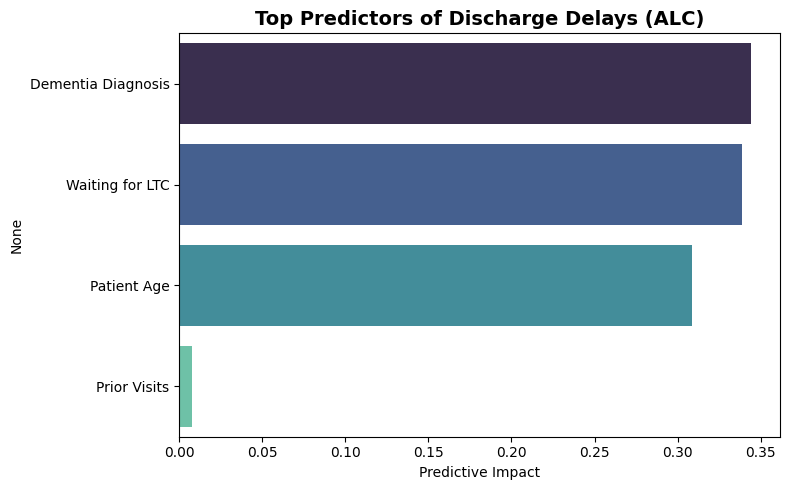

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. GENERATE DATA
np.random.seed(42)
n_patients = 1000
df = pd.DataFrame({
    'Age': np.random.normal(75, 10, n_patients).astype(int),
    'Has_Dementia': np.random.choice([0, 1], n_patients, p=[0.7, 0.3]),
    'Waiting_For_LTC': np.random.choice([0, 1], n_patients, p=[0.6, 0.4]),
    'Prior_Visits': np.random.randint(0, 5, n_patients)
})

# Define Target: Risk Score Calculation
def get_risk(row):
    risk = 0
    if row['Age'] > 80: risk += 25
    if row['Has_Dementia'] == 1: risk += 40
    if row['Waiting_For_LTC'] == 1: risk += 30
    return 1 if risk > 50 else 0

df['ALC_Flag'] = df.apply(get_risk, axis=1)

# 2. TRAIN MODEL
X = df[['Age', 'Has_Dementia', 'Waiting_For_LTC', 'Prior_Visits']]
y = df['ALC_Flag']
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, y)

# 3. CREATE CHART
plt.figure(figsize=(8, 5))
feat_import = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
# Rename for cleaner chart
feat_import.index = ['Dementia Diagnosis', 'Waiting for LTC', 'Patient Age', 'Prior Visits']
sns.barplot(x=feat_import, y=feat_import.index, palette='mako')
plt.title('Top Predictors of Discharge Delays (ALC)', fontsize=14, weight='bold')
plt.xlabel('Predictive Impact', fontsize=10)
plt.tight_layout()

# 4. SAVE IMAGE
plt.savefig('alc_chart.png', dpi=300)
print("Chart created successfully!")